# Caso di studio — anomaly detection sul compressore di un treno

**Caso di studio della Lezione 5.** Corso di AI applicata, Zucchetti Centro Sistemi.

Sette mesi di segnali del compressore di un treno della metropolitana di Porto, in servizio fra
febbraio e agosto 2020, e i rapporti dell'azienda di manutenzione, con quattro guasti. Il
reparto di manutenzione chiede **un alert abbastanza presto da programmare l'intervento, e
pochi falsi alert.**

Il notebook mette a confronto due detector sugli stessi dati: una regola scritta da chi conosce
la macchina, e un modello del comportamento normale addestrato sui dati. Entrambi sono valutati
guasto per guasto, con i falsi alert contati a settimana.

### I dati

**MetroPT-3**: i segnali dell'unità di produzione dell'aria (Air Production Unit) di un treno
della metropolitana di Porto, da febbraio ad agosto 2020. Sette segnali analogici — pressioni,
corrente del motore, temperatura dell'olio — e otto digitali, cioè stato delle valvole e segnali
elettrici. L'originale ha un campione ogni dieci secondi circa; la release
[`dati-metropt`](https://github.com/nunziati/zcs-ai-course-2026/releases/tag/dati-metropt)
contiene le medie al minuto.

> Davari, N., Veloso, B., Ribeiro, R. P., Pereira, P. M., Gama, J. *Predictive maintenance
> based on anomaly detection using deep learning for air production unit in the railway
> industry.* IEEE DSAA 2021.

Fonte: [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/791/metropt+3+dataset),
licenza [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/).

### Che cosa serve

`numpy`, `pandas`, `matplotlib` e `scikit-learn`, già preinstallati su Colab.


## 1 · Il caso e i dati

Il compressore dell'unità di produzione dell'aria riempie i serbatoi che alimentano i sistemi
pneumatici del treno, freni compresi. I rapporti dell'azienda di manutenzione riportano, per
ogni guasto, l'inizio e la fine.

La cella scarica i dati, carica le medie al minuto dei quindici segnali e scrive la tabella
dei guasti. Contiene anche le scelte del caso, che sono i punti di variazione dell'esercizio.


In [1]:
import pathlib, urllib.request, zipfile, io
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter
from sklearn.ensemble import IsolationForest

# PUNTO DI VARIAZIONE — le scelte del caso
FINESTRA      = "60min"                        # durata di una finestra: prova "30min" o "120min"
ADDESTRAMENTO = ("2020-02-01", "2020-03-31")   # il periodo da cui il modello impara il modello normale
SOGLIA_REGOLA = 0.9                            # quota di tempo in carico oltre la quale scatta la regola
PERCENTILE    = 99.5                           # soglia del modello: percentile dei punteggi di addestramento
PREAVVISO     = "24h"                          # un alert entro queste ore prima di un guasto è considerato utile

VALUTAZIONE_DA = "2020-04-01"   # inizio del periodo su cui sono valutati tutti i detector
PAUSA          = "3h"           # finestre segnalate a meno di questa distanza formano un alert solo
DOPO           = "24h"          # dopo la fine di un guasto, gli alert in questo tempo non sono falsi

D = pathlib.Path("dati-metropt")
if not (D / "metropt3-1min.csv").exists():
    U = "https://github.com/nunziati/zcs-ai-course-2026/releases/download/dati-metropt/metropt3.zip"
    with urllib.request.urlopen(U) as r: zipfile.ZipFile(io.BytesIO(r.read())).extractall(D)
m = pd.read_csv(D / "metropt3-1min.csv", index_col="timestamp", parse_dates=True)

# I guasti dei report di manutenzione, come riportati dalla documentazione del dataset.
GUASTI = pd.DataFrame(
    {"inizio": pd.to_datetime(["2020-04-18 00:00", "2020-05-29 23:30",
                               "2020-06-05 10:00", "2020-07-15 14:30"]),
     "fine":   pd.to_datetime(["2020-04-18 23:59", "2020-05-30 06:00",
                               "2020-06-07 14:30", "2020-07-15 19:00"])},
    index=pd.Index([1, 2, 3, 4], name="guasto"))

INK, MUTED, BLU, ROS = "#1f2933", "#77828c", "#2c5f8a", "#b8422f"
MESI = ["", "gennaio", "febbraio", "marzo", "aprile", "maggio", "giugno",
        "luglio", "agosto", "settembre", "ottobre", "novembre", "dicembre"]
plt.rcParams.update({"figure.dpi": 90, "font.size": 9, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.edgecolor": MUTED})

def num(x, cifre=1): return f"{x:.{cifre}f}".replace(".", ",")
def intero(x): return f"{int(x):,}".replace(",", ".")
def quando(t): return f"{t:%d/%m %H:%M}"
def ore(td): return td / pd.Timedelta("1h")
def elenco(v):
    v = [str(x) for x in v]
    return v[0] if len(v) == 1 else ", ".join(v[:-1]) + " e " + v[-1]
def asse_mesi(ax):
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: MESI[mdates.num2date(x).month][:3]))

giorni = (m.index.max() - m.index.min()).days
print(f"dal {m.index.min():%d/%m/%Y} al {m.index.max():%d/%m/%Y}: {giorni} giorni")
print(f"{intero(len(m))} minuti con almeno un campione su {intero(giorni * 1440)} "
      f"({len(m) / (giorni * 1440):.0%})")
print(f"{m.shape[1]} segnali: {', '.join(m.columns)}")
print("\nI guasti del report di manutenzione, tutti perdite d'aria:")
for g, s, e in zip(GUASTI.index, GUASTI.inizio, GUASTI.fine):
    print(f"  {g}   dal {quando(s)} al {quando(e)}   {num(ore(e - s))} ore")

dal 01/02/2020 al 01/09/2020: 213 giorni
252.720 minuti con almeno un campione su 306.720 (82%)
15 segnali: TP2, TP3, H1, DV_pressure, Reservoirs, Oil_temperature, Motor_current, COMP, DV_eletric, Towers, MPG, LPS, Pressure_switch, Oil_level, Caudal_impulses

I guasti del report di manutenzione, tutti perdite d'aria:
  1   dal 18/04 00:00 al 18/04 23:59   24,0 ore
  2   dal 29/05 23:30 al 30/05 06:00   6,5 ore
  3   dal 05/06 10:00 al 07/06 14:30   52,5 ore
  4   dal 15/07 14:30 al 15/07 19:00   4,5 ore


## 2 · Un ciclo del compressore

Il compressore lavora a cicli. Quando la pressione scende sotto 8,2 bar, un segnale di comando
lo mette **in carico**: aspira aria e riempie i serbatoi finché la pressione raggiunge il valore
di arresto, poi torna a vuoto. Il segnale `DV_eletric` vale 1 quando il compressore è in carico.

Una perdita d'aria svuota i serbatoi mentre il compressore li riempie. La pressione non
raggiunge più il valore di arresto, e il compressore resta in carico senza interruzioni: è così
che questo failure mode compare nei dati.


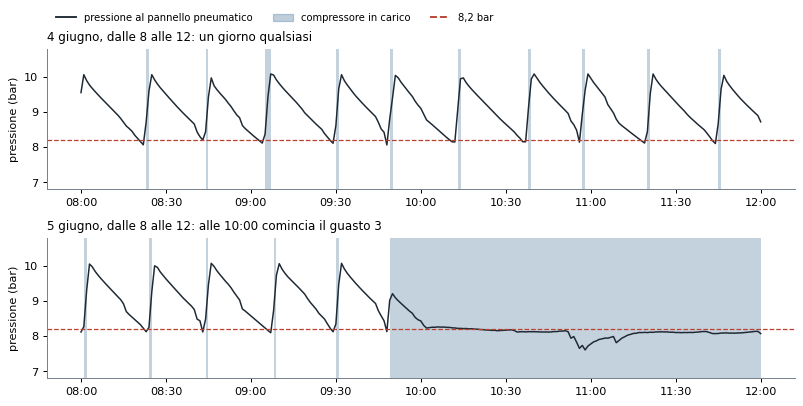

4 giugno: in carico il 9% del tempo, 10 entrate in carico in quattro ore, pressione fra 8,1 e 10,1 bar
5 giugno dalle 10: in carico il 100% del tempo, 0 entrate in carico, pressione fra 7,6 e 8,4 bar


In [2]:
normale = m.loc["2020-06-04 08:00":"2020-06-04 12:00"]
guasto = m.loc["2020-06-05 08:00":"2020-06-05 12:00"]

fig, ax = plt.subplots(2, 1, figsize=(9, 4.6), sharey=True)
for a, d, titolo in ((ax[0], normale, "4 giugno, dalle 8 alle 12: un giorno qualsiasi"),
                     (ax[1], guasto, "5 giugno, dalle 8 alle 12: alle 10:00 comincia il guasto 3")):
    a.fill_between(d.index, 6.8, 10.8, where=d.DV_eletric > 0.5, step="mid",
                   color=BLU, alpha=0.28, lw=0)
    a.plot(d.index, d.TP3, color=INK, lw=1.2)
    a.axhline(8.2, color=ROS, ls="--", lw=1)
    a.set_ylim(6.8, 10.8); a.set_ylabel("pressione (bar)")
    a.set_title(titolo, fontsize=9.5, loc="left")
    a.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax[0].legend([Line2D([], [], color=INK), plt.Rectangle((0, 0), 1, 1, color=BLU, alpha=0.3),
              Line2D([], [], color=ROS, ls="--")],
             ["pressione al pannello pneumatico", "compressore in carico", "8,2 bar"],
             frameon=False, fontsize=8, ncol=3, loc="upper left", bbox_to_anchor=(0, 1.32))
fig.tight_layout(); plt.show()

def ciclo(d):
    in_carico = (d.DV_eletric > 0.5).astype(int)
    return in_carico.mean(), int((in_carico.diff() == 1).sum()), d.TP3.min(), d.TP3.max()

q, n, lo, hi = ciclo(normale)
print(f"4 giugno: in carico il {q:.0%} del tempo, {n} entrate in carico in quattro ore, "
      f"pressione fra {num(lo)} e {num(hi)} bar")
q, n, lo, hi = ciclo(guasto.loc["2020-06-05 10:00":])
print(f"5 giugno dalle 10: in carico il {q:.0%} del tempo, {n} entrate in carico, "
      f"pressione fra {num(lo)} e {num(hi)} bar")

## 3 · Sette mesi di dati

Grafico sopra: la quota di ogni ora che il compressore passa in carico, per tutto il periodo. I
triangoli segnano gli episodi di carico continuo, cioè le ore di fila in carico per quasi
tutto il tempo: rossi quando il report registra un guasto, grigi altrimenti.
Grafico sotto: la temperatura mediana dell'olio, giorno per giorno.

Prima di qualunque modello, i dati mostrano:

- **episodi di carico continuo che il report non registra.** Il report è l'unica
  etichetta disponibile;
- **buchi, e ore con i valori congelati.** In alcune ore i valori restano identici: la temperatura dell'olio, per esempio, resta ferma anche a
  compressore spento, quando dovrebbe scendere;
- **un comportamento normale che varia con i mesi.** Da febbraio all'estate crescono la quota
  di tempo in carico e la temperatura dell'olio.


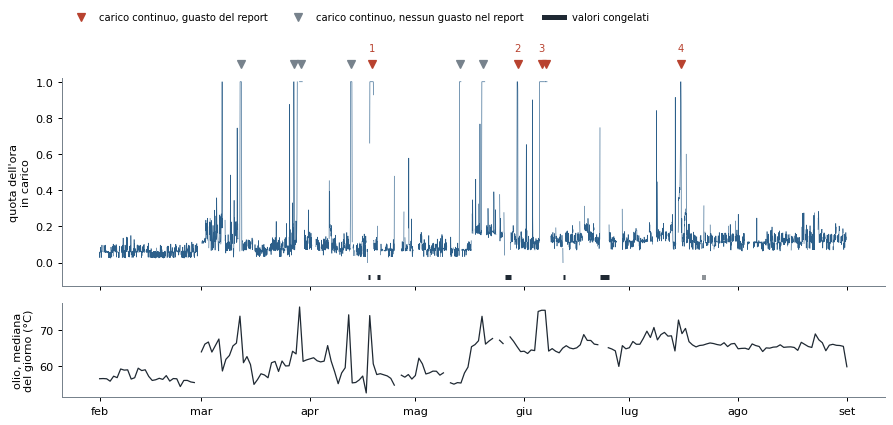

Episodi di almeno tre ore con il compressore in carico per almeno il 90% di ogni ora:
  12/03 01:00 -> 12/03 11:00    10 h   nessun guasto nel report
  27/03 08:00 -> 27/03 11:00     3 h   nessun guasto nel report
  28/03 23:00 -> 29/03 20:00    21 h   nessun guasto nel report
  12/04 12:00 -> 12/04 23:00    11 h   nessun guasto nel report
  18/04 01:00 -> 19/04 02:00    25 h   guasto 1 del report
  13/05 14:00 -> 14/05 01:00    11 h   nessun guasto nel report
  19/05 23:00 -> 20/05 20:00    21 h   nessun guasto nel report
  30/05 00:00 -> 30/05 06:00     6 h   guasto 2 del report
  05/06 10:00 -> 06/06 16:00    30 h   guasto 3 del report
  06/06 20:00 -> 07/06 14:00    18 h   guasto 3 del report
  15/07 15:00 -> 15/07 18:00     3 h   guasto 4 del report

Episodi senza un guasto nel report: 6 su 11.
Ore mancanti o incomplete: 992. Ore con i valori congelati: 164, in 7 tratti.

      mese   quota in carico, mediana   olio, mediana (°C)
  febbraio                       0,06              

In [3]:
ora = pd.DataFrame({
    "carico": m.DV_eletric.resample("1h").mean(),
    "olio":   m.Oil_temperature.resample("1h").mean(),
    "minuti": m.TP3.resample("1h").count(),
    "ferma":  (m.Oil_temperature.resample("1h").nunique() <= 1)
              & (m.TP3.resample("1h").nunique() <= 1),
})
mancanti = int(ore(m.index.max() - m.index.min())) - int((ora.minuti >= 45).sum())
ora = ora[ora.minuti >= 45]

def episodi(serie, pausa):
    """Gli istanti in cui la serie e' vera, raggruppati in intervalli (inizio, fine):
    due istanti a meno di pausa l'uno dall'altro cadono nello stesso intervallo."""
    gruppi = []
    for t in serie.index[serie.to_numpy(dtype=bool)]:
        if gruppi and t - gruppi[-1][1] <= pd.Timedelta(pausa): gruppi[-1][1] = t
        else: gruppi.append([t, t])
    return [tuple(x) for x in gruppi]

def guasto_di(a, b):
    """Il guasto del report che si sovrappone all'intervallo, oppure None."""
    for g, s, e in zip(GUASTI.index, GUASTI.inizio, GUASTI.fine):
        if a <= e and b >= s: return g
    return None

continui = [(a, b + pd.Timedelta("1h")) for a, b in episodi(ora.carico >= 0.9, "2h")
            if ore(b + pd.Timedelta("1h") - a) >= 3]
ferme = episodi(ora.ferma, "1h")

fig, ax = plt.subplots(2, 1, figsize=(10, 4.8), sharex=True,
                       gridspec_kw={"height_ratios": [2.2, 1]})
serie = ora.carico.where(~ora.ferma).asfreq("1h")     # buchi e ore congelate restano vuoti
ax[0].plot(serie.index, serie, color=BLU, lw=0.5)
scritti = set()
for a, b in continui:
    g = guasto_di(a, b)
    ax[0].plot(a + (b - a) / 2, 1.1, marker="v", ms=7, color=ROS if g else MUTED, clip_on=False)
    if g and g not in scritti:
        ax[0].text(a + (b - a) / 2, 1.17, str(g), color=ROS, ha="center", fontsize=8)
        scritti.add(g)
for a, b in ferme:
    ax[0].plot([a, b + pd.Timedelta("1h")], [-0.08, -0.08], color=INK, lw=4,
               solid_capstyle="butt")
ax[0].set_ylim(-0.13, 1.02); ax[0].set_ylabel("quota dell'ora\nin carico")
ax[0].legend([Line2D([], [], marker="v", ls="", color=ROS), Line2D([], [], marker="v", ls="", color=MUTED),
              Line2D([], [], color=INK, lw=4)],
             ["carico continuo, guasto del report", "carico continuo, nessun guasto nel report",
              "valori congelati"], frameon=False, fontsize=8, ncol=3, loc="upper left",
             bbox_to_anchor=(0, 1.36))
olio = ora.olio[~ora.ferma].resample("D").median()
ax[1].plot(olio.index, olio, color=INK, lw=1)
ax[1].set_ylabel("olio, mediana\ndel giorno (°C)")
asse_mesi(ax[1])
fig.tight_layout(); plt.show()

print("Episodi di almeno tre ore con il compressore in carico per almeno il 90% di ogni ora:")
for a, b in continui:
    g = guasto_di(a, b)
    print(f"  {quando(a)} -> {quando(b)}  {ore(b - a):4.0f} h   "
          + (f"guasto {g} del report" if g else "nessun guasto nel report"))
senza = [x for x in continui if guasto_di(*x) is None]
print(f"\nEpisodi senza un guasto nel report: {len(senza)} su {len(continui)}.")
print(f"Ore mancanti o incomplete: {intero(mancanti)}. Ore con i valori congelati: "
      f"{int(ora.ferma.sum())}, in {len(ferme)} tratti.")

valide = ora[~ora.ferma]
mese = valide.groupby(valide.index.month)[["carico", "olio"]].median()
mese = mese[valide.groupby(valide.index.month).size() >= 100]
print(f"\n{'mese':>10}{'quota in carico, mediana':>27}{'olio, mediana (°C)':>21}")
for k, r in mese.iterrows():
    print(f"{MESI[k]:>10}{num(r.carico, 2):>27}{num(r.olio):>21}")

## 4 · Finestre e split nel tempo

Il windowing taglia la serie in **finestre** di durata `FINESTRA`, e ogni finestra è
riassunta da poche grandezze, le **feature**: la quota di tempo in carico, il numero di entrate
in carico, la quota di tempo con il motore acceso, la corrente media, la temperatura media
dell'olio e la pressione minima. Ogni finestra porta l'istante in cui finisce, che è il primo
istante in cui un detector real-time può usarla.

Le finestre con meno di tre quarti dei minuti e quelle con i valori congelati sono tolte.

La macchina è una sola, quindi lo split per unità non esiste e l'unico split possibile è nel
tempo. Il modello è addestrato su `ADDESTRAMENTO`, un periodo senza guasti nel rapporto, e
entrambi i detector sono valutati sullo stesso periodo, dal 1° aprile in poi.


In [4]:
def finestre(m, durata):
    r = m.resample(durata)
    in_carico = (m.DV_eletric > 0.5).astype(int)
    w = pd.DataFrame({
        "carico":        r.DV_eletric.mean(),
        "avvii":         (in_carico.diff() == 1).resample(durata).sum(),
        "motore":        (m.Motor_current > 1).resample(durata).mean(),
        "corrente":      r.Motor_current.mean(),
        "olio":          r.Oil_temperature.mean(),
        "pressione_min": r.TP3.min(),
    })
    minuti = r.TP3.count()
    ferma = (r.Oil_temperature.nunique() <= 1) & (r.TP3.nunique() <= 1)
    piena = minuti >= 0.75 * ore(pd.Timedelta(durata)) * 60
    w = w[piena & ~ferma]
    w.index = w.index + pd.Timedelta(durata)      # l'istante in cui la finestra finisce
    return w, int((minuti > 0).sum()), int((piena & ferma).sum())

w, n_con_dati, n_ferme = finestre(m, FINESTRA)
F = list(w.columns)
assert pd.Timestamp(ADDESTRAMENTO[1]) < pd.Timestamp(VALUTAZIONE_DA), \
    "il periodo di addestramento deve finire prima del periodo di valutazione"
addestra = w.loc[ADDESTRAMENTO[0]:ADDESTRAMENTO[1]]
valuta_w = w.loc[VALUTAZIONE_DA:]
settimane = len(valuta_w) * pd.Timedelta(FINESTRA) / pd.Timedelta("7D")

SIGNIFICATO = {"carico": "quota di tempo in carico", "avvii": "entrate in carico",
               "motore": "quota di tempo con il motore acceso",
               "corrente": "corrente media del motore (A)",
               "olio": "temperatura media dell'olio (°C)",
               "pressione_min": "pressione minima al pannello (bar)"}
print(f"finestre di {FINESTRA}: {intero(n_con_dati)} con dati, {intero(len(w))} tenute, "
      f"{n_ferme} tolte perché congelate, le altre perché incomplete\n")
print(f"{'feature':<15}{'che cosa misura':<38}{'mediana, addestramento':>24}{'valutazione':>13}")
for f in F:
    print(f"{f:<15}{SIGNIFICATO[f]:<38}{num(addestra[f].median(), 2):>24}"
          f"{num(valuta_w[f].median(), 2):>13}")
print(f"\naddestramento: dal {pd.Timestamp(ADDESTRAMENTO[0]):%d/%m} al "
      f"{pd.Timestamp(ADDESTRAMENTO[1]):%d/%m}, {intero(len(addestra))} finestre")
print(f"valutazione:   dal {pd.Timestamp(VALUTAZIONE_DA):%d/%m} alla fine, "
      f"{intero(len(valuta_w))} finestre, {num(settimane)} settimane di dati, "
      f"{len(GUASTI)} guasti nel report")

finestre di 60min: 4.416 con dati, 3.959 tenute, 164 tolte perché congelate, le altre perché incomplete

feature        che cosa misura                         mediana, addestramento  valutazione
carico         quota di tempo in carico                                  0,07         0,12
avvii          entrate in carico                                         2,00         3,00
motore         quota di tempo con il motore acceso                       0,33         0,48
corrente       corrente media del motore (A)                             1,36         2,00
olio           temperatura media dell'olio (°C)                         58,49        64,97
pressione_min  pressione minima al pannello (bar)                        8,10         8,14

addestramento: dal 01/02 al 31/03, 1.208 finestre
valutazione:   dal 01/04 alla fine, 2.751 finestre, 16,4 settimane di dati, 4 guasti nel report


## 5 · La valutazione per evento

Il reparto di manutenzione conta guasti e ispezioni, e la valutazione conta le stesse cose.

- **Alert.** Finestre segnalate a meno di `PAUSA` l'una dall'altra formano un alert solo: il
  reparto riceve una singola segnalazione.
- **Guasto rilevato.** Un guasto è rilevato se un alert cade fra `PREAVVISO` prima del suo
  inizio e la sua fine. L'**anticipo** è la distanza fra il primo di questi alert e l'inizio
  riportato: positivo se l'alert arriva prima, negativo se arriva a guasto già cominciato.
- **Falso alert.** Un alert lontano da tutti i guasti. Gli alert nelle `DOPO` ore dopo la fine
  di un guasto non sono contati come falsi, perché riguardano ancora lo stesso guasto. I falsi
  alert sono contati a settimana.

La valutazione punto per punto, finestra per finestra, pesa ogni guasto per la sua durata. La
cella lo mostra sui guasti del report, e definisce le funzioni usate da qui in avanti.


In [5]:
def valuta(allerta, nome):
    """allerta: serie vera o falsa sulle finestre del periodo di valutazione."""
    ep = episodi(allerta, PAUSA)
    pre, dopo = pd.Timedelta(PREAVVISO), pd.Timedelta(DOPO)
    righe = []
    for g, s, e in zip(GUASTI.index, GUASTI.inizio, GUASTI.fine):
        utili = [a for a, b in ep if a <= e and b >= s - pre]
        primo = max(utili[0], s - pre) if utili else pd.NaT
        righe.append({"guasto": g, "inizio": s, "primo alert": primo, "anticipo": ore(s - primo)})
    falsi = [(a, b) for a, b in ep
             if not any(a <= e + dopo and b >= s - pre for s, e in zip(GUASTI.inizio, GUASTI.fine))]
    return {"nome": nome, "guasti": pd.DataFrame(righe).set_index("guasto"),
            "episodi": ep, "falsi": falsi, "falsi_sett": len(falsi) / settimane}

def rilevati(esito): return int(esito["guasti"]["primo alert"].notna().sum())

def stampa(esito):
    print(esito["nome"])
    print(f"  {'guasto':>6}   {'inizio riportato':<18}{'primo alert':<14}{'anticipo':>9}")
    for g, r in esito["guasti"].iterrows():
        if pd.isna(r["primo alert"]):
            print(f"  {g:>6}   {quando(r.inizio):<18}{'nessuno':<14}{'mancato':>9}")
        else:
            print(f"  {g:>6}   {quando(r.inizio):<18}{quando(r['primo alert']):<14}"
                  f"{num(r.anticipo) + ' h':>9}")
    print(f"  guasti rilevati: {rilevati(esito)} su {len(GUASTI)}")
    print(f"  falsi alert: {len(esito['falsi'])} in {num(settimane)} settimane, "
          f"{num(esito['falsi_sett'], 2)} a settimana")

def linea_del_tempo(esiti):
    fig, ax = plt.subplots(figsize=(10, 0.55 * len(esiti) + 1.1))
    for g, s, e in zip(GUASTI.index, GUASTI.inizio, GUASTI.fine):
        ax.axvspan(s, e, color=ROS, alpha=0.3, lw=0)
        ax.axvline(s, color=ROS, lw=0.8)
        ax.text(s, len(esiti) - 0.4, f" {g}", color=ROS, fontsize=8)
    for k, es in enumerate(esiti):
        y = len(esiti) - 1 - k
        for a, b in es["episodi"]:
            col = INK if (a, b) in es["falsi"] else BLU
            ax.plot([a - pd.Timedelta(FINESTRA), b], [y, y], color=col, lw=7, solid_capstyle="butt")
            ax.plot(b, y, marker="|", ms=12, mew=1.5, color=col)
    ax.set_yticks(range(len(esiti)))
    ax.set_yticklabels([es["nome"] for es in esiti][::-1], fontsize=8.5)
    ax.set_ylim(-0.7, len(esiti) - 0.15)
    ax.set_xlim(pd.Timestamp(VALUTAZIONE_DA), m.index.max())
    ax.spines["left"].set_visible(False); ax.tick_params(axis="y", length=0)
    asse_mesi(ax)
    ax.legend([Line2D([], [], color=BLU, lw=6), Line2D([], [], color=INK, lw=6),
               plt.Rectangle((0, 0), 1, 1, color=ROS, alpha=0.4)],
              ["alert utile", "falso alert", "guasto del report"], frameon=False,
              fontsize=8, ncol=3, loc="upper left", bbox_to_anchor=(0, 1 + 0.55 / len(esiti)))
    fig.tight_layout(); plt.show()

durata = ore(GUASTI.fine - GUASTI.inizio)
peso = durata / durata.sum()
print("Punto per punto ogni finestra conta uguale, e ogni guasto pesa quanto dura:")
for g in GUASTI.index:
    print(f"  guasto {g}: {num(durata[g])} ore, {peso[g]:.0%} delle finestre di guasto")
g_max = peso.idxmax()
print(f"\nUn detector che rileva solo il guasto {g_max} ha una recall punto per punto del "
      f"{peso[g_max]:.0%}, e per evento del {1 / len(GUASTI):.0%}.")

Punto per punto ogni finestra conta uguale, e ogni guasto pesa quanto dura:
  guasto 1: 24,0 ore, 27% delle finestre di guasto
  guasto 2: 6,5 ore, 7% delle finestre di guasto
  guasto 3: 52,5 ore, 60% delle finestre di guasto
  guasto 4: 4,5 ore, 5% delle finestre di guasto

Un detector che rileva solo il guasto 3 ha una recall punto per punto del 60%, e per evento del 25%.


## 6 · La regola del tecnico

La baseline è la regola che scriverebbe chi conosce la macchina: **un alert quando il
compressore resta in carico per più di `SOGLIA_REGOLA` della finestra.** Non richiede
addestramento, e rileva un solo failure mode: il compressore che non torna a vuoto.

La cella guarda anche le 12 ore prima di ogni guasto, per vedere se il ciclo del compressore
cambia prima dell'inizio riportato.


regola: in carico oltre 90% della finestra
  guasto   inizio riportato  primo alert    anticipo
       1   18/04 00:00       18/04 02:00      -2,0 h
       2   29/05 23:30       30/05 01:00      -1,5 h
       3   05/06 10:00       05/06 11:00      -1,0 h
       4   15/07 14:30       15/07 16:00      -1,5 h
  guasti rilevati: 4 su 4
  falsi alert: 6 in 16,4 settimane, 0,37 a settimana


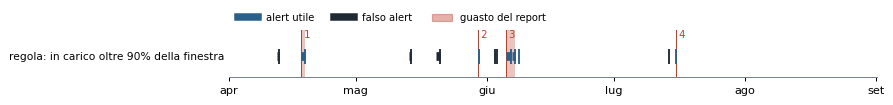

I falsi alert cominciano il 12/04, 13/05, 20/05, 02/06, 03/06, 14/07.
In quelle ore il compressore è rimasto in carico, e il report non registra niente:
sono falsi rispetto al report, e il report non dice che cosa sia successo.

La quota di carico fra 12 ore e 60 minuti prima dell'inizio di ogni guasto (mediana del periodo di valutazione: 0,12):
  guasto 1: 0 finestre valide, i dati mancano o sono congelati
  guasto 2: mediana 0,12, massimo 0,15
  guasto 3: mediana 0,11, massimo 0,14
  guasto 4: mediana 0,40, massimo 0,50

La regola rileva i guasti a guasto già cominciato, con un ritardo fra 1,0 e 2,0 ore: il ritardo è il tempo che serve
a riempire una finestra con il compressore in carico.

Prima dell'inizio riportato, la quota di carico supera il doppio della mediana solo per il guasto 4.
Per gli altri il ciclo resta quello di sempre, oppure i dati mancano: nelle ore
precedenti non c'è niente che un detector possa usare per anticipare.


In [6]:
regola = valuta(valuta_w.carico >= SOGLIA_REGOLA,
                f"regola: in carico oltre {num(SOGLIA_REGOLA * 100, 0)}% della finestra")
stampa(regola)
linea_del_tempo([regola])

if regola["falsi"]:
    print("I falsi alert cominciano il " + ", ".join(f"{a:%d/%m}" for a, _ in regola["falsi"]) + ".")
    print("In quelle ore il compressore è rimasto in carico, e il report non registra niente:")
    print("sono falsi rispetto al report, e il report non dice che cosa sia successo.\n")

riferimento = valuta_w.carico.median()
minuti = int(ore(pd.Timedelta(FINESTRA)) * 60)
print(f"La quota di carico fra 12 ore e {minuti} minuti prima dell'inizio di ogni guasto "
      f"(mediana del periodo di valutazione: {num(riferimento, 2)}):")
cambia = []
for g, s in zip(GUASTI.index, GUASTI.inizio):
    prima = w.loc[s - pd.Timedelta("12h"): s - pd.Timedelta(FINESTRA), "carico"]
    if len(prima) < 3:
        print(f"  guasto {g}: {len(prima)} finestre valide, i dati mancano o sono congelati")
        continue
    print(f"  guasto {g}: mediana {num(prima.median(), 2)}, massimo {num(prima.max(), 2)}")
    if prima.max() > 2 * riferimento: cambia.append(g)

anticipi = regola["guasti"].anticipo.dropna()
if len(anticipi) and (anticipi <= 0).all():
    print(f"\nLa regola rileva i guasti a guasto già cominciato, con un ritardo fra "
          f"{num(-anticipi.max())} e {num(-anticipi.min())} ore: il ritardo è il tempo che serve")
    print("a riempire una finestra con il compressore in carico.")
if cambia:
    print(f"\nPrima dell'inizio riportato, la quota di carico supera il doppio della mediana solo per "
          + ("il guasto " if len(cambia) == 1 else "i guasti ") + elenco(cambia) + ".")
    print("Per gli altri il ciclo resta quello di sempre, oppure i dati mancano: nelle ore")
    print("precedenti non c'è niente che un detector possa usare per anticipare.")

## 7 · Un modello del normale

Il secondo detector non conosce il failure mode. Un modello impara dal periodo di
addestramento com'è fatta una finestra normale, e segnala le finestre che non le somigliano.

Il modello è un **Isolation Forest**: un insieme di alberi che dividono le finestre con tagli
casuali sulle feature. Una finestra anomala resta isolata dopo pochi tagli, mentre una normale
ne richiede molti, e il punteggio di anomalia cresce quanto meno tagli servono. La soglia è il
percentile `PERCENTILE` dei punteggi sul periodo di addestramento: con `PERCENTILE = 99.5`, una
finestra di addestramento su duecento la supera.


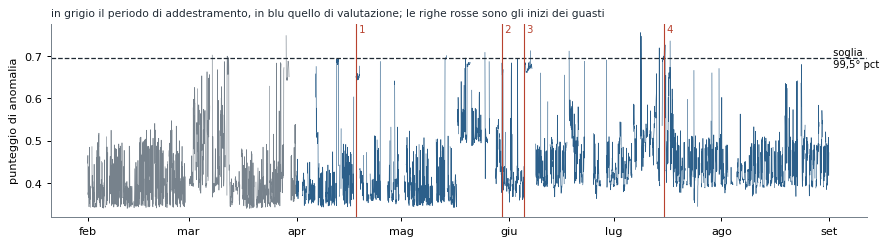

modello, addestrato su febbraio e marzo
  guasto   inizio riportato  primo alert    anticipo
       1   18/04 00:00       nessuno         mancato
       2   29/05 23:30       nessuno         mancato
       3   05/06 10:00       07/06 04:00     -42,0 h
       4   15/07 14:30       15/07 06:00       8,5 h
  guasti rilevati: 2 su 4
  falsi alert: 9 in 16,4 settimane, 0,55 a settimana


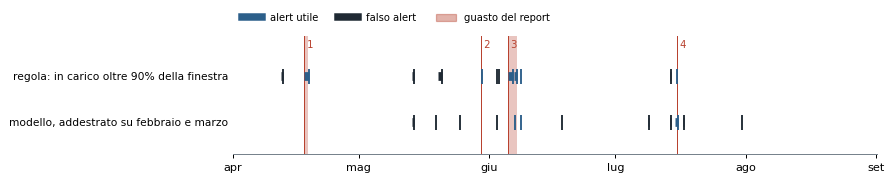

Il modello non rileva i guasti 1 e 2. Nel periodo di addestramento ci sono 36 finestre con il compressore
in carico per almeno il 90% del tempo, nei giorni 06/03, 12/03, 27/03, 28/03, 29/03.
Il modello le ha imparate come normali, e il carico continuo non è più un'anomalia.

Guasto 4: il primo alert arriva 8,5 ore prima dell'inizio riportato,
e la regola non lo vede ancora. Le finestre fra l'alert e l'inizio del guasto:
  15/07 06:00   in carico  38%   motore acceso 100%   olio 72,1 °C
  15/07 07:00   in carico  40%   motore acceso 100%   olio 72,6 °C
  15/07 08:00   in carico  39%   motore acceso 100%   olio 72,9 °C
  15/07 09:00   in carico  42%   motore acceso 100%   olio 73,2 °C
  15/07 10:00   in carico  42%   motore acceso 100%   olio 73,6 °C
  15/07 11:00   in carico  40%   motore acceso 100%   olio 73,9 °C
  15/07 12:00   in carico  48%   motore acceso 100%   olio 74,3 °C
  15/07 13:00   in carico  50%   motore acceso 100%   olio 75,5 °C
  15/07 14:00   in carico  65%   motore 

In [7]:
def modello_del_normale(periodo):
    """Isolation Forest addestrato sulle finestre del periodo; punteggio alto = anomalo."""
    tr = w.loc[periodo[0]:periodo[1]]
    mod = IsolationForest(n_estimators=200, random_state=0).fit(tr[F])
    punteggio = pd.Series(-mod.score_samples(w[F]), index=w.index)
    return punteggio, np.percentile(punteggio.loc[periodo[0]:periodo[1]], PERCENTILE)

def nome_periodo(p):
    a, b = pd.Timestamp(p[0]).month, pd.Timestamp(p[1]).month
    if a == b: return f"su {MESI[a]}"
    if b == a + 1: return f"su {MESI[a]} e {MESI[b]}"
    return f"da {MESI[a]} a{'d' if MESI[b][0] in 'aeiou' else ''} {MESI[b]}"

punteggio, soglia = modello_del_normale(ADDESTRAMENTO)
modello = valuta(punteggio.loc[VALUTAZIONE_DA:] > soglia,
                 f"modello, addestrato {nome_periodo(ADDESTRAMENTO)}")

fig, ax = plt.subplots(figsize=(10, 2.8))
p = punteggio.asfreq(FINESTRA)
ax.plot(p.loc[:ADDESTRAMENTO[1]].index, p.loc[:ADDESTRAMENTO[1]], color=MUTED, lw=0.5)
ax.plot(p.loc[VALUTAZIONE_DA:].index, p.loc[VALUTAZIONE_DA:], color=BLU, lw=0.5)
ax.axhline(soglia, color=INK, ls="--", lw=1)
ax.text(m.index.max(), soglia, f" soglia\n {num(PERCENTILE)}° pct", va="center", fontsize=8)
for g, s in zip(GUASTI.index, GUASTI.inizio):
    ax.axvline(s, color=ROS, lw=0.9)
    ax.text(s, ax.get_ylim()[1], f" {g}", color=ROS, fontsize=8, va="top")
ax.set_ylabel("punteggio di anomalia"); asse_mesi(ax)
ax.set_title("in grigio il periodo di addestramento, in blu quello di valutazione; "
             "le righe rosse sono gli inizi dei guasti", fontsize=8.5, loc="left", color=INK)
fig.tight_layout(); plt.show()

stampa(modello)
linea_del_tempo([regola, modello])

mancati = [g for g, r in modello["guasti"].iterrows() if pd.isna(r["primo alert"])]
alti = addestra[addestra.carico >= 0.9]
if mancati:
    print(f"Il modello non rileva {'il guasto' if len(mancati) == 1 else 'i guasti'} "
          f"{elenco(mancati)}.", end=" ")
    if len(alti):
        print(f"Nel periodo di addestramento ci sono {len(alti)} finestre con il compressore")
        print(f"in carico per almeno il 90% del tempo, nei giorni "
              f"{', '.join(sorted({f'{t:%d/%m}' for t in alti.index}))}.")
        print("Il modello le ha imparate come normali, e il carico continuo non è più un'anomalia.")
    else:
        print()
for g, r in modello["guasti"].iterrows():
    if pd.notna(r["primo alert"]) and 2 <= r.anticipo < ore(pd.Timedelta(PREAVVISO)):
        print(f"\nGuasto {g}: il primo alert arriva {num(r.anticipo)} ore prima dell'inizio riportato,")
        print("e la regola non lo vede ancora. Le finestre fra l'alert e l'inizio del guasto:")
        tra = w.loc[r["primo alert"]:r.inizio, ["carico", "motore", "olio"]]
        for t, q in tra.iterrows():
            print(f"  {quando(t)}   in carico {q.carico:4.0%}   motore acceso {q.motore:4.0%}   "
                  f"olio {num(q.olio)} °C")
        print("Il motore resta acceso e la quota di carico cresce: la regola guarda solo la")
        print("seconda, il modello tutte le feature insieme.")

## 8 · Che cosa il modello impara come normale

Lo stesso modello, addestrato su due periodi diversi, entrambi senza guasti nel report:
febbraio e marzo insieme, oppure solo febbraio. Il confronto separa due problemi che ogni
modello del normale incontra in produzione.

- **Contaminazione.** Se il periodo di addestramento contiene anomalie, il modello le impara
  come normali e poi non le segnala.
- **Drift.** Se il comportamento normale cambia dopo l'addestramento, il modello segnala come
  anomalo anche il nuovo comportamento normale, e i falsi alert crescono con il tempo.


detector                                     rilevati   anticipo per guasto (ore)    falsi alert/sett.
regola: in carico oltre 90% della finestra      4 su 4      -2,0   -1,5   -1,0   -1,5              0,37
modello, addestrato su febbraio e marzo         2 su 4        --     --  -42,0    8,5              0,55
modello, addestrato su febbraio                 4 su 4      -1,0   24,0   -1,0   15,5              8,79


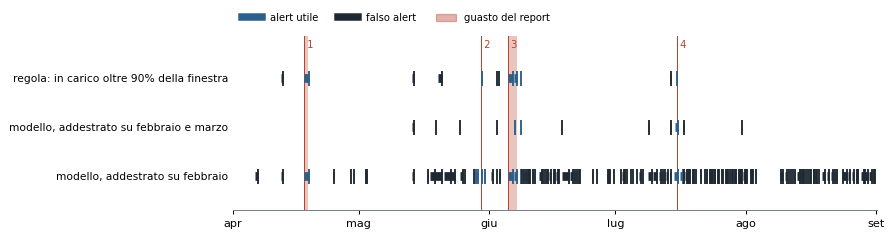

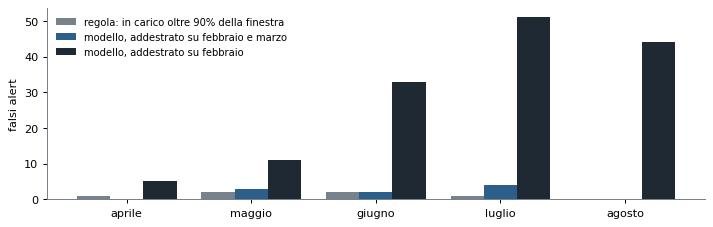


Febbraio e luglio a confronto, mediane delle finestre: quota in carico 0,06 e 0,12, entrate in carico 2 e 3,
motore acceso 30% e 52%, olio 56,7 e 67,0 °C.

Addestrato su febbraio e marzo, il modello rileva 2 guasti su 4: marzo contiene ore di carico continuo,
e il modello le ha imparate come normali.
Addestrato su febbraio, ne rileva 4 su 4, ma produce 8,8 falsi alert a settimana, più di tutti a luglio:
il normale di luglio è diverso da quello di febbraio, e il modello lo segnala come anomalo.

modello, addestrato su febbraio: sul guasto 2 l'anticipo è di 24 ore, il massimo misurabile.
Vuol dire che un alert era già aperto quando è cominciato il preavviso, e con 8,8 falsi alert
a settimana questo succede anche per caso.


In [8]:
PERIODI = [("2020-02-01", "2020-03-31"), ("2020-02-01", "2020-02-29")]
if tuple(ADDESTRAMENTO) not in PERIODI: PERIODI.append(tuple(ADDESTRAMENTO))
esiti = [regola]
for per in PERIODI:
    p, s = modello_del_normale(per)
    esiti.append(valuta(p.loc[VALUTAZIONE_DA:] > s, f"modello, addestrato {nome_periodo(per)}"))

print(f"{'detector':<44}{'rilevati':>9}   {'anticipo per guasto (ore)':<28}{'falsi alert/sett.':>18}")
for es in esiti:
    ant = "".join(f"{'--' if pd.isna(a) else num(a):>7}" for a in es["guasti"].anticipo)
    print(f"{es['nome']:<44}{rilevati(es):>5} su {len(GUASTI)}   {ant:<28}{num(es['falsi_sett'], 2):>18}")
linea_del_tempo(esiti)

mesi = range(pd.Timestamp(VALUTAZIONE_DA).month, m.index.max().month)
fig, ax = plt.subplots(figsize=(8, 2.6))
larg = 0.8 / len(esiti)
for k, (es, col) in enumerate(zip(esiti, [MUTED, BLU, INK, ROS])):
    conta = pd.Series([a.month for a, _ in es["falsi"]], dtype=int).value_counts()
    ax.bar([x + k * larg for x in mesi], [conta.get(x, 0) for x in mesi], width=larg,
           color=col, label=es["nome"])
ax.set_xticks([x + larg * (len(esiti) - 1) / 2 for x in mesi])
ax.set_xticklabels([MESI[x] for x in mesi]); ax.set_ylabel("falsi alert")
ax.legend(frameon=False, fontsize=8); fig.tight_layout(); plt.show()

feb, lug = w.loc["2020-02"], w.loc["2020-07"]
print(f"\nFebbraio e luglio a confronto, mediane delle finestre: quota in carico "
      f"{num(feb.carico.median(), 2)} e {num(lug.carico.median(), 2)}, entrate in carico "
      f"{num(feb.avvii.median(), 0)} e {num(lug.avvii.median(), 0)},")
print(f"motore acceso {feb.motore.median():.0%} e {lug.motore.median():.0%}, olio "
      f"{num(feb.olio.median())} e {num(lug.olio.median())} °C.")
lungo, corto = esiti[1], esiti[2]
if rilevati(lungo) < rilevati(corto):
    print(f"\nAddestrato {nome_periodo(PERIODI[0])}, il modello rileva {rilevati(lungo)} guasti su "
          f"{len(GUASTI)}: marzo contiene ore di carico continuo,")
    print("e il modello le ha imparate come normali.")
if corto["falsi_sett"] > 2 * lungo["falsi_sett"]:
    picco = pd.Series([a.month for a, _ in corto["falsi"]]).value_counts().idxmax()
    print(f"Addestrato {nome_periodo(PERIODI[1])}, ne rileva {rilevati(corto)} su {len(GUASTI)}, ma "
          f"produce {num(corto['falsi_sett'], 1)} falsi alert a settimana, più di tutti a {MESI[picco]}:")
    print(f"il normale di {MESI[picco]} è diverso da quello di febbraio, e il modello lo segnala come anomalo.")
h = ore(pd.Timedelta(PREAVVISO))
for es in esiti[1:]:
    pieni = [g for g, a in es["guasti"].anticipo.items() if a == h]
    if pieni:
        print(f"\n{es['nome']}: sul guasto {elenco(pieni)} l'anticipo è di {h:.0f} ore, il massimo "
              "misurabile.")
        print(f"Vuol dire che un alert era già aperto quando è cominciato il preavviso, e con "
              f"{num(es['falsi_sett'], 1)} falsi alert")
        print("a settimana questo succede anche per caso.")

## 9 · Anticipo contro falsi alert: la soglia — si può saltare

Ogni soglia produce un punto: quanti guasti rileva, e quanti falsi alert a settimana costa.
Con una soglia più bassa i guasti rilevati aumentano e l'alert arriva prima, ma aumentano anche
i falsi alert.

La scelta del punto richiede due costi che il notebook non conosce: quello di un falso alert,
cioè un'ispezione inutile, e quello di un guasto non rilevato, che si manifesta in servizio.
La soglia la decide il reparto di manutenzione con quei costi; i detector forniscono solo la
curva.


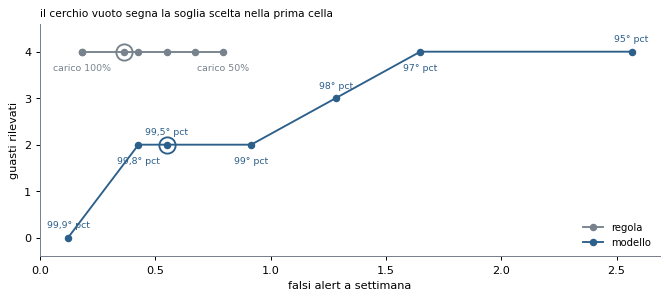

detector  soglia         rilevati  falsi/sett.  anticipo massimo (ore)
regola    carico 50%        4 su 4         0,79                     1,5
regola    carico 60%        4 su 4         0,67                     0,5
regola    carico 70%        4 su 4         0,55                    -0,5
regola    carico 80%        4 su 4         0,43                    -0,5
regola    carico 90%        4 su 4         0,37                    -1,0
regola    carico 95%        4 su 4         0,18                    -1,0
regola    carico 100%       4 su 4         0,18                    -1,0
modello   95° pct           4 su 4         2,56                    14,5
modello   97° pct           4 su 4         1,65                    13,5
modello   98° pct           3 su 4         1,28                    13,5
modello   99° pct           2 su 4         0,92                    13,5
modello   99,5° pct         2 su 4         0,55                     8,5
modello   99,8° pct         2 su 4         0,43                  

In [9]:
righe = []
for q in (0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 1.0):
    es = valuta(valuta_w.carico >= q, "")
    righe.append(("regola", q, f"carico {q:.0%}", rilevati(es), es["falsi_sett"],
                  es["guasti"].anticipo.max()))
tr = punteggio.loc[ADDESTRAMENTO[0]:ADDESTRAMENTO[1]]
for pc in (95, 97, 98, 99, 99.5, 99.8, 99.9):
    es = valuta(punteggio.loc[VALUTAZIONE_DA:] > np.percentile(tr, pc), "")
    righe.append(("modello", pc, f"{pc:g}° pct".replace(".", ","), rilevati(es), es["falsi_sett"],
                  es["guasti"].anticipo.max()))
curva = pd.DataFrame(righe, columns=["detector", "valore", "soglia", "rilevati", "falsi_sett", "anticipo_max"])

fig, ax = plt.subplots(figsize=(7.5, 3.4))
for det, col in (("regola", MUTED), ("modello", BLU)):
    c = curva[curva.detector == det]
    ax.plot(c.falsi_sett, c.rilevati, "o-", color=col, label=det, ms=5)
    scelta = c[c.valore == (SOGLIA_REGOLA if det == "regola" else PERCENTILE)]
    ax.plot(scelta.falsi_sett, scelta.rilevati, "o", ms=13, mfc="none", mec=col, mew=1.5)
    for k, (_, r) in enumerate((c if det == "modello" else c.iloc[[0, -1]]).iterrows()):
        sopra = det == "modello" and k % 2 == 0          # etichette alternate, per non sovrapporle
        ax.annotate(r.soglia, (r.falsi_sett, r.rilevati), fontsize=7.5, color=col, ha="center",
                    xytext=(0, 8 if sopra else -15), textcoords="offset points")
ax.set_xlim(left=0)
ax.set_xlabel("falsi alert a settimana"); ax.set_ylabel("guasti rilevati")
ax.set_yticks(range(len(GUASTI) + 1)); ax.set_ylim(-0.4, len(GUASTI) + 0.6)
ax.set_title("il cerchio vuoto segna la soglia scelta nella prima cella", fontsize=8.5, loc="left")
ax.legend(frameon=False, fontsize=8, loc="lower right"); fig.tight_layout(); plt.show()

print(f"{'detector':<10}{'soglia':<14}{'rilevati':>9}{'falsi/sett.':>13}{'anticipo massimo (ore)':>24}")
for _, r in curva.iterrows():
    am = "--" if pd.isna(r.anticipo_max) else num(r.anticipo_max)
    print(f"{r.detector:<10}{r.soglia:<14}{r.rilevati:>5} su {len(GUASTI)}{num(r.falsi_sett, 2):>13}{am:>24}")

h = ore(pd.Timedelta(PREAVVISO))
peggio = curva.loc[curva.falsi_sett.idxmax()]
print(f"\nCon {num(peggio.falsi_sett, 1)} falsi alert a settimana, nelle {h:.0f} ore prima di un guasto ne "
      f"cadono in media {num(peggio.falsi_sett * h / 168, 1)} per caso.")
print("Un anticipo misurato con tanti falsi alert non si distingue dal caso, e deve essere")
print("letto sempre insieme al numero di falsi alert.")

## 10 · Discussione

### Domande per la chat

**1. Addestrato su febbraio e marzo, con le scelte di partenza, il modello non rileva due
guasti su quattro. Perché?**

- A. Isolation Forest è troppo semplice per questi dati.
- B. Nel periodo di addestramento ci sono già ore di carico continuo, e il modello le ha
  imparate come normali.
- C. Quei due guasti durano troppo poco.

**B.** Il modello impara come normale tutto il periodo di addestramento, anomalie comprese.
Il carico continuo di marzo, che il report non registra, è entrato nell'addestramento, e da
quel momento non è più un'anomalia.

**2. La regola rileva i guasti a guasto già cominciato. Che cosa servirebbe per avere l'alert
prima?**

- A. Una soglia più bassa.
- B. Un segnale che cambi prima dell'inizio del guasto.
- C. Finestre più corte.

**B.** Un detector può anticipare un guasto solo se i dati cambiano prima che il guasto
cominci. Prima del guasto 4 il motore resta acceso e la quota di carico cresce, ed è lì che il
modello del normale arriva prima della regola. Prima dei guasti 2 e 3 il ciclo è quello di
sempre, e prima del guasto 1 i dati sono congelati.
Finestre più corte riducono il ritardo, ma l'alert arriva comunque dopo l'inizio.

**3. Chi sceglie la soglia?**

- A. Chi sviluppa il modello, massimizzando una metrica.
- B. Il reparto di manutenzione, confrontando il costo di un'ispezione inutile con quello di un
  guasto in servizio.
- C. Il modello, dalla quota di anomalie che stima nei dati.

**B.** La curva della sezione 9 dice come si muovono i due errori al variare della soglia.
Quanto pesa ciascuno lo sa chi paga le ispezioni e i guasti.

### Che cosa cambia in produzione

- **Il feedback dei tecnici.** Ogni alert chiuso con un esito — guasto, anomalia senza guasto,
  niente — diventa un'etichetta. Gli episodi di carico continuo senza report sono i casi su
  cui oggi quel feedback manca.
- **Il controllo dei dati prima del detector.** Buchi e valori congelati devono essere
  rilevati prima di arrivare al modello: altrimenti diventano alert, oppure entrano
  nell'addestramento.
- **Il riaddestramento.** Il modello del normale deve essere riaddestrato dopo ogni intervento
  e quando i falsi alert crescono, su un periodo controllato: la contaminazione e il drift della
  sezione 8 sono i due modi in cui un modello fermo peggiora.
- **Regola e modello insieme.** La regola copre il failure mode noto con pochi falsi alert; il
  modello del normale serve per i failure mode che nessuno ha ancora scritto in una regola.
